# ***1. Importing Libraries***

In [73]:
import os
from Bio import SeqIO
from glob import glob
from Bio.Data import CodonTable
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
import pandas as pd
from scipy.stats import shapiro, mannwhitneyu
from statsmodels.stats.multitest import multipletests


In [74]:
import warnings
warnings.filterwarnings("ignore",category=RuntimeWarning)

# ***2. Loading The DATASET***

In [75]:

# add ".." because jupyter notebook works in the current directory only
# ".." causes it to go back to one 

rscu_avg_gyrA = pd.read_csv(os.path.join("..","results","CSVs","rscu_avg_gyrA.csv"),index_col=0)
rscu_avg_katG = pd.read_csv(os.path.join("..","results","CSVs","rscu_avg_katG.csv"),index_col=0)
rscu_avg_rpoB = pd.read_csv(os.path.join("..","results","CSVs","rscu_avg_rpoB.csv"),index_col=0)
rscu_all_samples = pd.read_csv(os.path.join("..","results","CSVs","rscu_all_samples.csv"))
enc_gc3_all_samples = pd.read_csv(os.path.join("..","results","CSVs","enc_gc3_all_samples.csv"))

### ***2.1 Checking the datasets***

In [76]:
# Shape
print("rscu_avg_gyrA:",rscu_avg_gyrA.shape)
print("rscu_avg_katG:",rscu_avg_katG.shape)
print("rscu_avg_rpoB:",rscu_avg_rpoB.shape)
print("rscu_all_samples:",rscu_all_samples.shape)
print("enc_gc3_all_samples:",enc_gc3_all_samples.shape)

rscu_avg_gyrA: (61, 2)
rscu_avg_katG: (61, 2)
rscu_avg_rpoB: (58, 2)
rscu_all_samples: (17579, 5)
enc_gc3_all_samples: (100, 8)


In [77]:
# Type of datatype
print("rscu_avg_gyrA:\n",rscu_avg_gyrA.dtypes)
# print("\nrscu_avg_katG:\n",rscu_avg_katG.dtypes)
# print("\nrscu_avg_rpoB:\n",rscu_avg_rpoB.dtypes)
print("\nrscu_all_samples:\n",rscu_all_samples.dtypes)
print("\nenc_gc3_all_samples:\n",enc_gc3_all_samples.dtypes)

rscu_avg_gyrA:
 Sensitive    float64
Resistant    float64
dtype: object

rscu_all_samples:
 Sample_Id        str
Group            str
Gene             str
Codon            str
RSCU         float64
dtype: object

enc_gc3_all_samples:
 Sample_ID        str
Group            str
enc_rpoB     float64
gc3_rpoB     float64
enc_katG     float64
gc3_katG     float64
enc_gyrA     float64
gc3_gyrA     float64
dtype: object


### ***2.2 Creating the new columns***

In [78]:
rscu_all_samples["third_base"] = rscu_all_samples["Codon"].str[-1]
rscu_all_samples["base_category"] = rscu_all_samples["third_base"].map({
    "A" : "AT-ending",
    "T" : "AT-ending",
    "C" : "CG-ending",
    "G" : "CG-ending"
})
# rscu_all_samples.head()

In [79]:
rscu_avg_katG["Difference"] = rscu_avg_katG["Resistant"] - rscu_avg_katG["Sensitive"]
rscu_avg_katG["Absolute_Difference"] = rscu_avg_katG["Difference"].abs()
rscu_avg_katG["Percent_Change"] = ((rscu_avg_katG["Resistant"] - rscu_avg_katG["Sensitive"]) / rscu_avg_katG["Sensitive"])*100
# rscu_avg_katG.sort_values("Absolute_Difference",ascending=False).head(20)

rscu_avg_gyrA["Difference"] = rscu_avg_gyrA["Resistant"] - rscu_avg_gyrA["Sensitive"]
rscu_avg_gyrA["Absolute_Difference"] = rscu_avg_gyrA["Difference"].abs()
rscu_avg_gyrA["Percent_Change"] = ((rscu_avg_gyrA["Resistant"] - rscu_avg_gyrA["Sensitive"]) / rscu_avg_gyrA["Sensitive"])*100
# rscu_avg_gyrA.sort_values("Absolute_Difference",ascending=False).head(10)

rscu_avg_rpoB["Difference"] = rscu_avg_rpoB["Resistant"] - rscu_avg_rpoB["Sensitive"]
rscu_avg_rpoB["Absolute_Difference"] = rscu_avg_rpoB["Difference"].abs()
rscu_avg_rpoB["Percent_Change"] = ((rscu_avg_rpoB["Resistant"] - rscu_avg_rpoB["Sensitive"]) / rscu_avg_rpoB["Sensitive"])*100
# rscu_avg_rpoB.sort_values("Absolute_Difference",ascending=False).head(10)

In [80]:
rscu_avg_rpoB = rscu_avg_rpoB.reset_index()
rscu_avg_rpoB = rscu_avg_rpoB.rename(columns={"index":"Codon"})
rscu_avg_rpoB["third_base"] = rscu_avg_rpoB["Codon"].str[-1]
rscu_avg_rpoB["base_category"] = rscu_avg_rpoB["third_base"].map({
    "A" : "AT-ending",
    "T" : "AT-ending",
    "C" : "CG-ending",
    "G" : "CG-ending"
})

rscu_avg_katG = rscu_avg_katG.reset_index()
rscu_avg_katG = rscu_avg_katG.rename(columns={"index":"Codon"})
rscu_avg_katG["third_base"] = rscu_avg_katG["Codon"].str[-1]
rscu_avg_katG["base_category"] = rscu_avg_katG["third_base"].map({
    "A" : "AT-ending",
    "T" : "AT-ending",
    "C" : "CG-ending",
    "G" : "CG-ending"
})
rscu_avg_gyrA = rscu_avg_gyrA.reset_index()
rscu_avg_gyrA = rscu_avg_gyrA.rename(columns={"index":"Codon"})
rscu_avg_gyrA["third_base"] = rscu_avg_gyrA["Codon"].str[-1]
rscu_avg_gyrA["base_category"] = rscu_avg_gyrA["third_base"].map({
    "A" : "AT-ending",
    "T" : "AT-ending",
    "C" : "CG-ending",
    "G" : "CG-ending"})

In [81]:

codon_table = CodonTable.unambiguous_dna_by_name["Standard"]
aa_to_codons_std = defaultdict(list)
for codon, aa in codon_table.forward_table.items():
    aa_to_codons_std[aa].append(codon)

aa_grp_sizes = defaultdict(float)
for aa, codon_list in aa_to_codons_std.items():
    aa_grp_sizes[aa] = len(codon_list)

# aa_grp_sizes
codon_to_aa = codon_table.forward_table
# codon_to_aa


In [82]:
rscu_avg_rpoB["Amino_acid"] = rscu_avg_rpoB["Codon"].map(codon_to_aa)

rscu_avg_gyrA["Amino_acid"] = rscu_avg_gyrA["Codon"].map(codon_to_aa)

rscu_avg_katG["Amino_acid"] = rscu_avg_katG["Codon"].map(codon_to_aa)

In [83]:
rscu_avg_rpoB["n_codons"] = rscu_avg_rpoB["Amino_acid"].map(aa_grp_sizes)

rscu_avg_gyrA["n_codons"] = rscu_avg_gyrA["Amino_acid"].map(aa_grp_sizes)

rscu_avg_katG["n_codons"] = rscu_avg_katG["Amino_acid"].map(aa_grp_sizes)

In [84]:
rscu_avg_rpoB["sensitive_frac"] = rscu_avg_rpoB["Sensitive"] / rscu_avg_rpoB["n_codons"]
rscu_avg_rpoB["resistant_frac"] = rscu_avg_rpoB["Resistant"] / rscu_avg_rpoB["n_codons"]

rscu_avg_gyrA["sensitive_frac"] = rscu_avg_gyrA["Sensitive"] / rscu_avg_gyrA["n_codons"]
rscu_avg_gyrA["resistant_frac"] = rscu_avg_gyrA["Resistant"] / rscu_avg_gyrA["n_codons"]

rscu_avg_katG["sensitive_frac"] = rscu_avg_katG["Sensitive"] / rscu_avg_katG["n_codons"]
rscu_avg_katG["resistant_frac"] = rscu_avg_katG["Resistant"] / rscu_avg_katG["n_codons"]

In [85]:
rscu_avg_rpoB[rscu_avg_rpoB["Amino_acid"] == "L"]["sensitive_frac"].sum()

np.float64(0.9983333333333332)

# ***3. PLOTS***

In [86]:
# x = rscu_avg_rpoB["Sensitive"]
# y = rscu_avg_rpoB["Resistant"]

# max_val = max(x.max(),y.max())
# plt.figure(figsize=(7,5))
# plt.plot([0,max_val],[0,max_val],color="crimson", linestyle="--", label="y = x")
# plt.scatter(x,y,color="royalblue", alpha=0.7)
# plt.xlabel("Sensitive RSCU")
# plt.ylabel("Resistant RSCU")
# plt.title("RSCU: Sensitive vs Resistant (rpoB)")
# plt.xlim(0, max_val)
# plt.ylim(0, max_val)
# plt.show()


#### ***3.1 RSCU Scatter Plots***

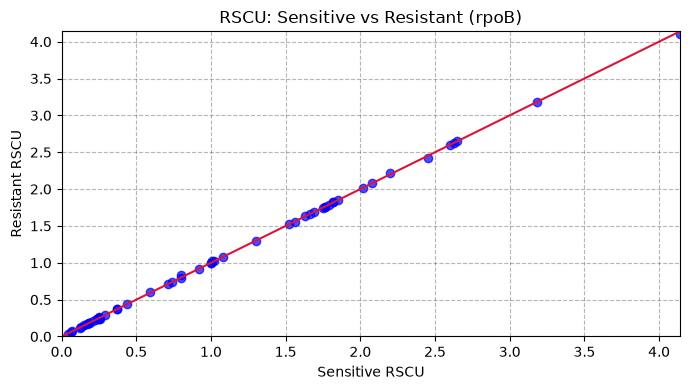

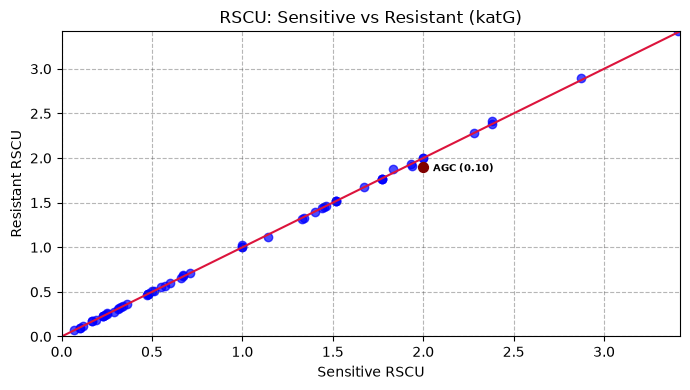

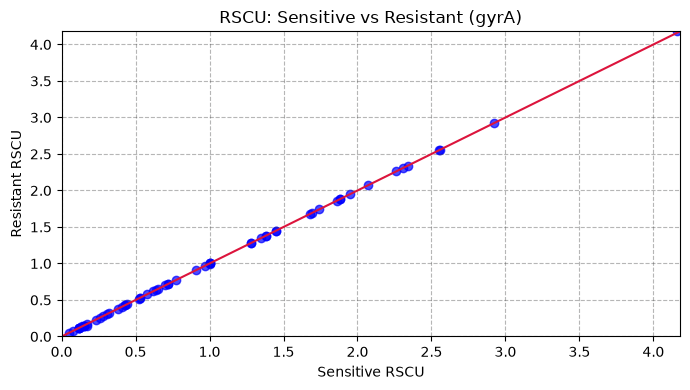

In [87]:
data = [
    ("rpoB",rscu_avg_rpoB),
    ("katG",rscu_avg_katG),
    ("gyrA",rscu_avg_gyrA)
]

for gene,dataset in data:
    x = dataset["Sensitive"]
    y = dataset["Resistant"]
    plt.figure(figsize=(7,4))
    max_val = max(x.max(),y.max())
    plt.plot([0,max_val],[0,max_val],color="crimson", linestyle="-", label="y = x")
    plt.scatter(x,y,color="blue", alpha=0.7)
    plt.xlabel("Sensitive RSCU")
    plt.ylabel("Resistant RSCU")
    plt.title(f"RSCU: Sensitive vs Resistant ({gene})")
    plt.xlim(0, max_val)
    plt.ylim(0, max_val)
    plt.grid(True,linestyle="--",alpha=0.4,color="#494a4a")
    for codon in dataset.index:
        xi = dataset.loc[codon,"Sensitive"]
        yi = dataset.loc[codon,"Resistant"]
        codon = dataset.loc[codon,"Codon"]
        if abs(xi - yi) > 0.1:
            plt.scatter(xi,yi, color = "maroon",s = 50, zorder = 5)
            plt.annotate(f"{codon} ({abs(xi-yi):.2f})",(xi,yi), fontsize=7,
                         xytext=(7,-3),textcoords="offset points",
                         fontweight = "bold")
    plt.tight_layout()
    plt.savefig(os.path.join("..","results","plots",f"rscu_scatter_{gene}.png"),dpi=300,bbox_inches="tight")
    plt.show()

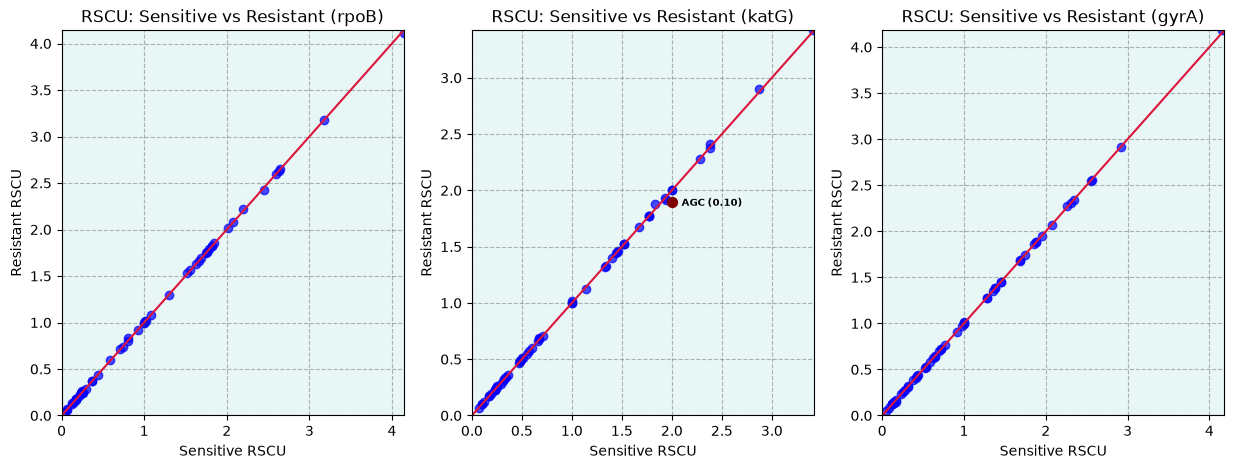

In [88]:
fig, axes  = plt.subplots(1,3,figsize=(15,5))

data = [
    ("rpoB",rscu_avg_rpoB),
    ("katG",rscu_avg_katG),
    ("gyrA",rscu_avg_gyrA)
]

for i, (gene,dataset) in enumerate(data):
    x = dataset["Sensitive"]
    y = dataset["Resistant"]
    ax = axes[i]
    max_val = max(x.max(),y.max())
    ax.plot([0,max_val],[0,max_val],color="crimson", linestyle="-", label="y = x")
    ax.scatter(x,y,color="blue", alpha=0.7)
    ax.set_xlabel("Sensitive RSCU")
    ax.set_ylabel("Resistant RSCU")
    ax.set_title(f"RSCU: Sensitive vs Resistant ({gene})")
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.grid(True,linestyle="--",alpha=0.4,color="#494a4a")
    ax.set_facecolor("#e8f6f6")
    for codon in dataset.index:
        xi = dataset.loc[codon,"Sensitive"]
        yi = dataset.loc[codon,"Resistant"]
        codon = dataset.loc[codon,"Codon"]
        if abs(xi - yi) > 0.1:
            ax.scatter(xi,yi, color = "maroon",s = 50, zorder = 5)
            ax.annotate(f"{codon} ({abs(xi-yi):.2f})",(xi,yi), fontsize=7,
                         xytext=(7,-3),textcoords="offset points",
                         fontweight = "bold")
plt.savefig(os.path.join("..","results","plots","rscu_scatter_all.png"),dpi=300,bbox_inches="tight")
plt.show()

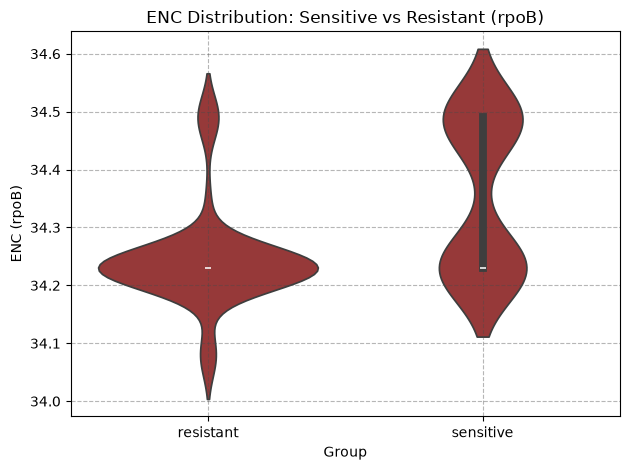

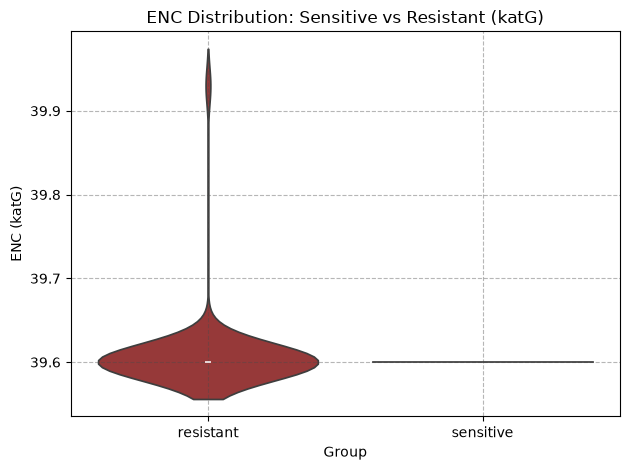

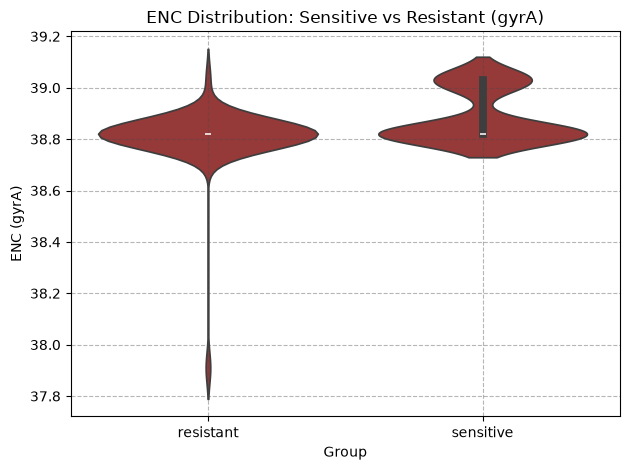

In [89]:
y_axis = ["enc_rpoB","enc_katG","enc_gyrA"]

for i in y_axis:
    gene = i.split("_")[1]
    sns.violinplot(data=enc_gc3_all_samples,x="Group",y=i,color="brown")
    plt.title(f"ENC Distribution: Sensitive vs Resistant ({gene})")
    plt.xlabel("Group")
    plt.ylabel(f"ENC ({gene})")
    plt.grid(True,linestyle="--",alpha=0.4,color="#494a4a")
    plt.tight_layout()
    plt.savefig(os.path.join("..", "results", "plots", f"enc_violin_{gene}.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()  


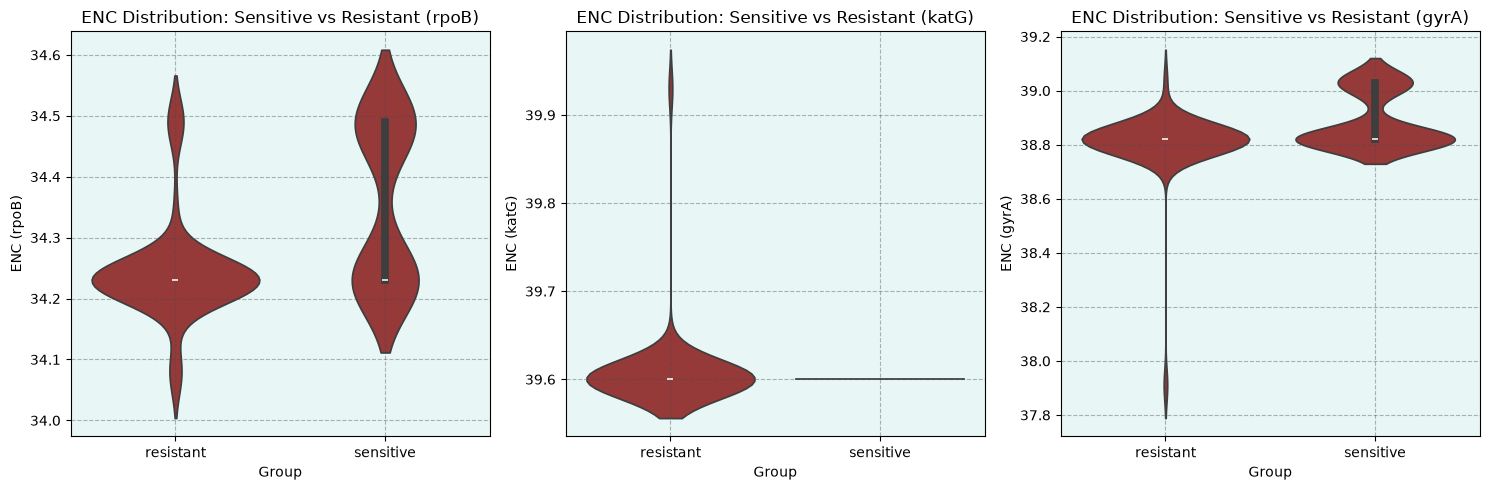

In [90]:
fig, axes  = plt.subplots(1,3,figsize=(15,5))
y_axis = ["enc_rpoB","enc_katG","enc_gyrA"]

for i, enc in enumerate(y_axis):
    ax = axes[i]
    gene = enc.split("_")[1]
    sns.violinplot(data=enc_gc3_all_samples,x="Group",y=enc,ax=ax,color="brown")
    ax.set_title(f"ENC Distribution: Sensitive vs Resistant ({gene})")
    ax.set_xlabel("Group")
    ax.set_ylabel(f"ENC ({gene})")
    ax.grid(True,linestyle="--",alpha=0.4,color="#494a4a")
    ax.set_facecolor("#e8f6f6")
    
plt.tight_layout()
plt.savefig(os.path.join("..", "results", "plots", f"enc_violin_all.png"), dpi=300, bbox_inches="tight")
plt.show()
  

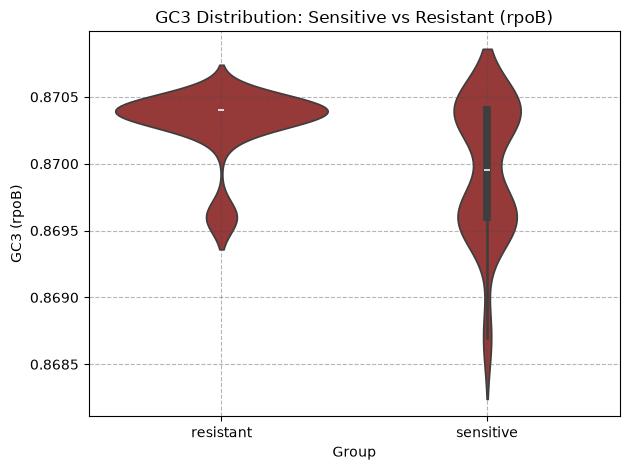

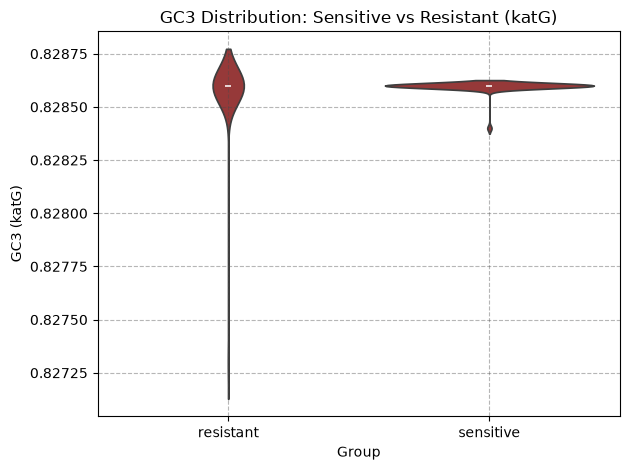

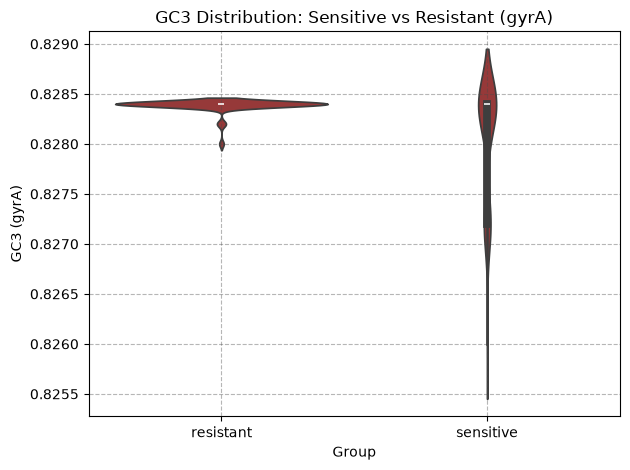

In [91]:
y_axis = ["gc3_rpoB","gc3_katG","gc3_gyrA"]

for i in y_axis:
    gene = i.split("_")[1]
    sns.violinplot(data=enc_gc3_all_samples,x="Group",y=i,color="brown")
    plt.title(f"GC3 Distribution: Sensitive vs Resistant ({gene})")
    plt.xlabel("Group")
    plt.ylabel(f"GC3 ({gene})")
    plt.grid(True,linestyle="--",alpha=0.4,color="#494a4a")
    plt.tight_layout()
    plt.savefig(os.path.join("..", "results", "plots", f"gc3_violin_{gene}.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

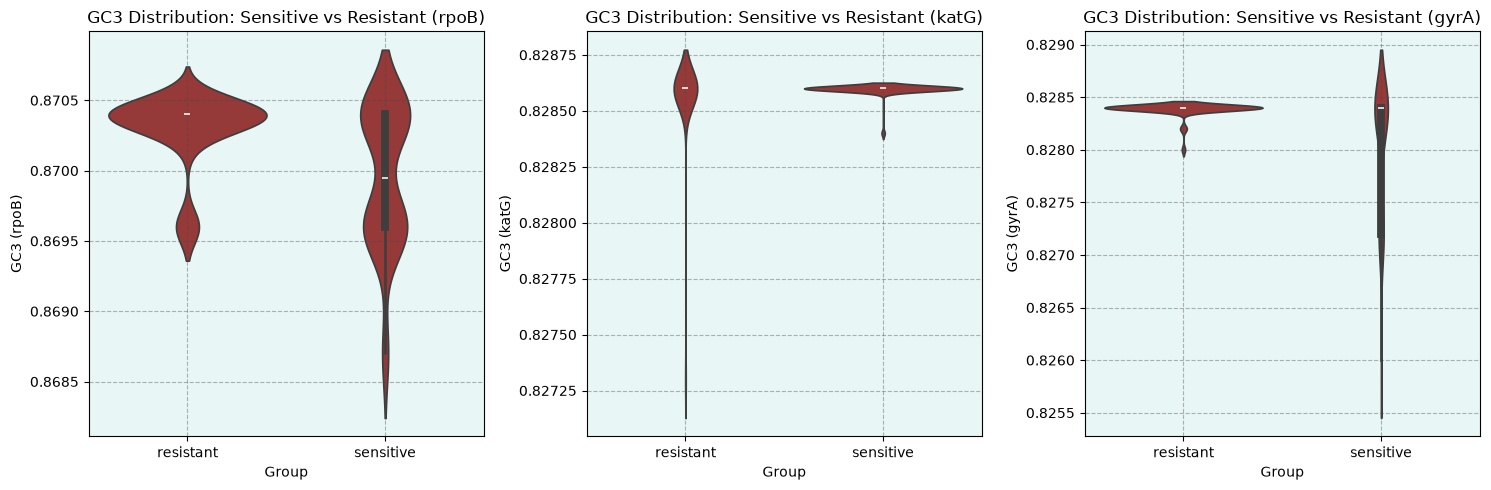

In [92]:
fig, axes  = plt.subplots(1,3,figsize=(15,5))
y_axis = ["gc3_rpoB","gc3_katG","gc3_gyrA"]

for i, enc in enumerate(y_axis):
    ax = axes[i]
    gene = enc.split("_")[1]
    sns.violinplot(data=enc_gc3_all_samples,x="Group",y=enc,ax=ax,color="brown")
    ax.set_title(f"GC3 Distribution: Sensitive vs Resistant ({gene})")
    ax.set_xlabel("Group")
    ax.set_ylabel(f"GC3 ({gene})")
    ax.grid(True,linestyle="--",alpha=0.4,color="#494a4a")
    ax.set_facecolor("#e8f6f6")
    
plt.tight_layout()
plt.savefig(os.path.join("..", "results", "plots", f"gc3_violin_all.png"), dpi=300, bbox_inches="tight")
plt.show()

In [93]:
rscu_all_samples.head()

,Sample_Id,Group,Gene,Codon,RSCU,third_base,base_category
0,ERR4810461,resistant,rpoB,TTG,0.86,G,CG-ending
1,ERR4810461,resistant,rpoB,GCA,0.24,A,AT-ending
2,ERR4810461,resistant,rpoB,GAT,0.21,T,AT-ending
3,ERR4810461,resistant,rpoB,TCC,1.54,C,CG-ending
4,ERR4810461,resistant,rpoB,CGC,3.18,C,CG-ending


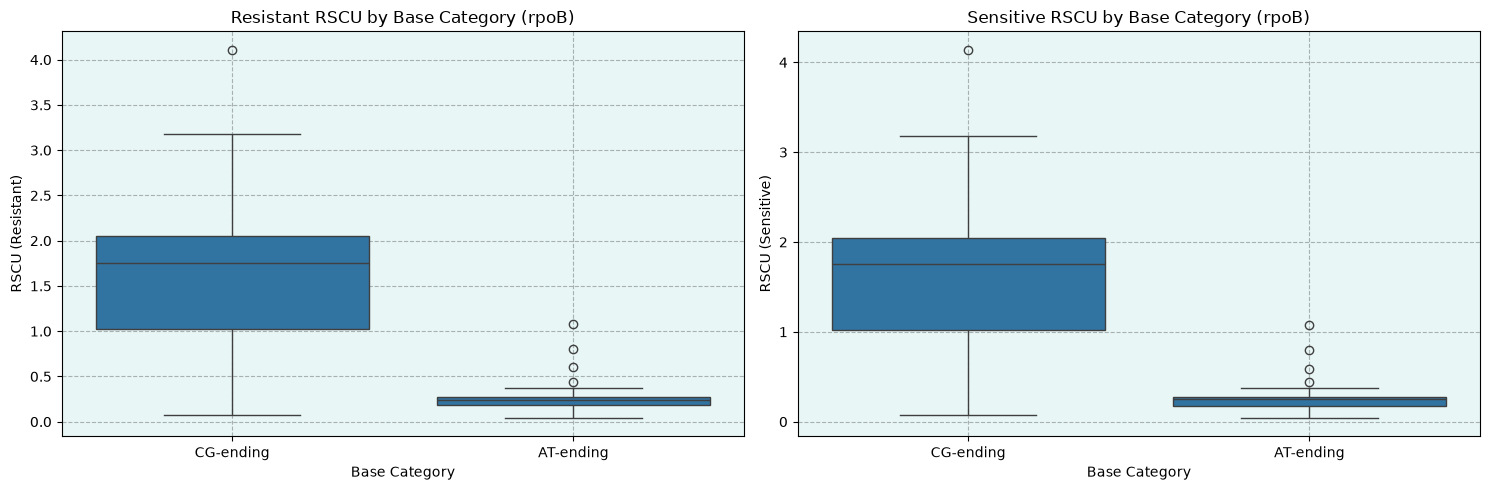

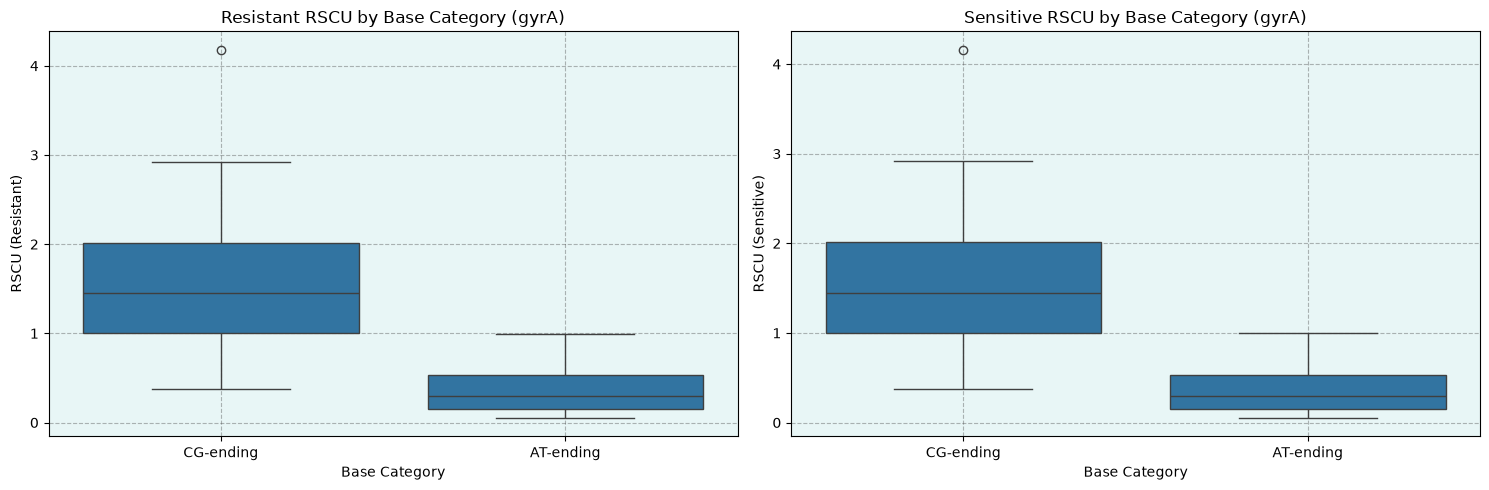

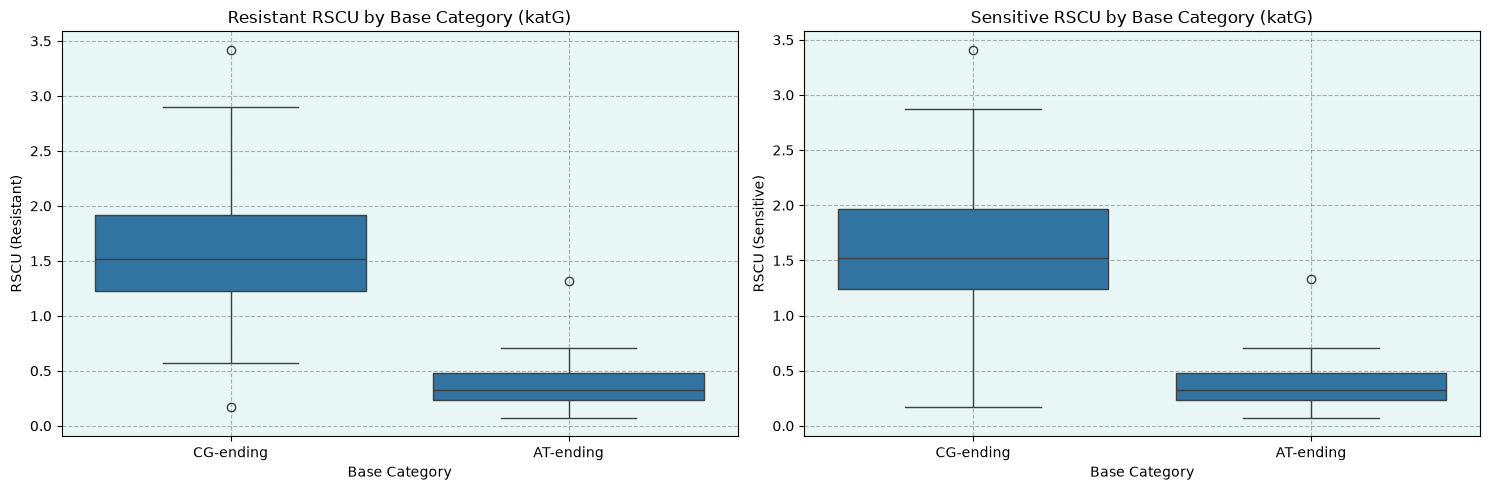

In [94]:
grps = ["Resistant","Sensitive"]
rscu_data = [("rpoB", rscu_avg_rpoB), ("gyrA", rscu_avg_gyrA), ("katG", rscu_avg_katG)]


for gene, data in rscu_data:
    fig, axes  = plt.subplots(1,2,figsize=(15,5))
    for i, grp in enumerate(grps):
        ax = axes[i]
        sns.boxplot(data=data,x="base_category",y=grp,ax=ax)
        ax.set_title(f"{grp} RSCU by Base Category ({gene})")
        ax.set_xlabel("Base Category")
        ax.set_ylabel(f"RSCU ({grp})")
        ax.grid(True,linestyle="--",alpha=0.4,color="#494a4a")
        ax.set_facecolor("#e8f6f6")   
    plt.tight_layout()
    plt.savefig(os.path.join("..", "results", "plots", f"rscu_basecategory_{gene}.png"), dpi=300, bbox_inches="tight")
    plt.show()



In [95]:
all_codons_std = set(codon for codons in aa_to_codons_std.values() for codon in codons)
present_codons = set(rscu_avg_rpoB["Codon"])
missing_codons = all_codons_std - present_codons
missing_codons

{'AGA', 'ATA', 'TTA'}

In [96]:
all_codons_std = set(codon for codons in aa_to_codons_std.values() for codon in codons)
present_codons = set(rscu_avg_katG["Codon"])
missing_codons = all_codons_std - present_codons
missing_codons

set()

In [97]:
all_codons_std = set(codon for codons in aa_to_codons_std.values() for codon in codons)
present_codons = set(rscu_avg_gyrA["Codon"])
missing_codons = all_codons_std - present_codons
missing_codons

set()

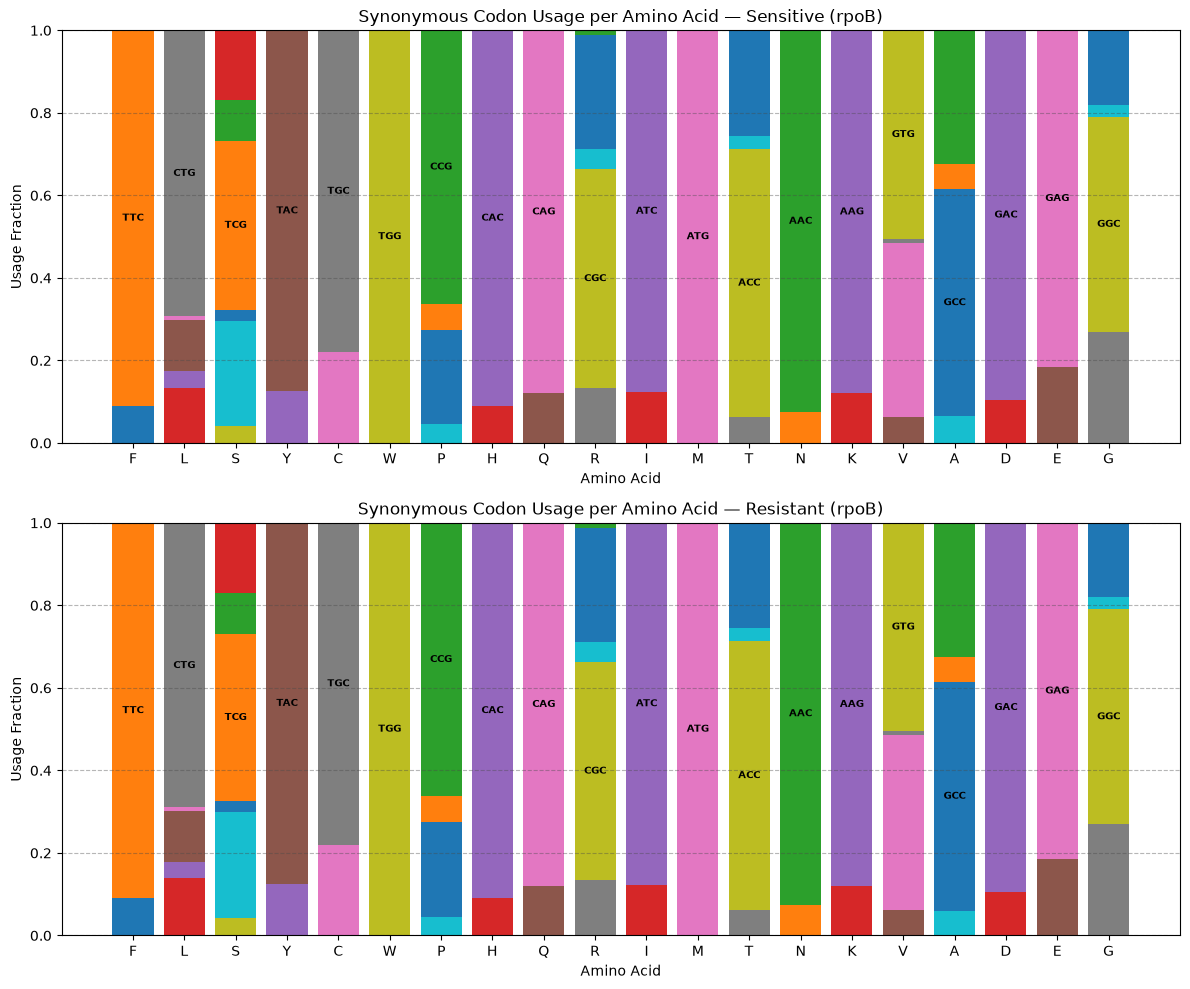

In [98]:
col = ["sensitive_frac","resistant_frac"]
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for i, grp in enumerate(col):
    ax = axes[i]
    label = grp.replace("_frac","").capitalize()
    for x in aa_to_codons_std:
        bottom = 0
        all_heights = []
        for codon in aa_to_codons_std[x]:
            match = rscu_avg_rpoB.loc[rscu_avg_rpoB["Codon"] == codon, grp]
            height = match.values[0] if not match.empty else 0
            all_heights.append(height)

        max_height = max(all_heights)

        for ht,codon in zip(all_heights,aa_to_codons_std[x]):
            ax.bar(x,height=ht,bottom=bottom)
            if ht == max_height:
                ax.text(x, bottom + ht/2, codon, ha="center", va="center", fontsize=7,fontweight="bold")
            bottom += ht
    ax.set_title(f"Synonymous Codon Usage per Amino Acid — {label} (rpoB)")
    ax.set_xlabel("Amino Acid")
    ax.set_ylabel("Usage Fraction")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4,color="#494a4a")
plt.tight_layout()
plt.savefig(os.path.join("..", "results", "plots", "codon_usage_stacked_rpoB.png"), dpi=300, bbox_inches="tight")
plt.show()


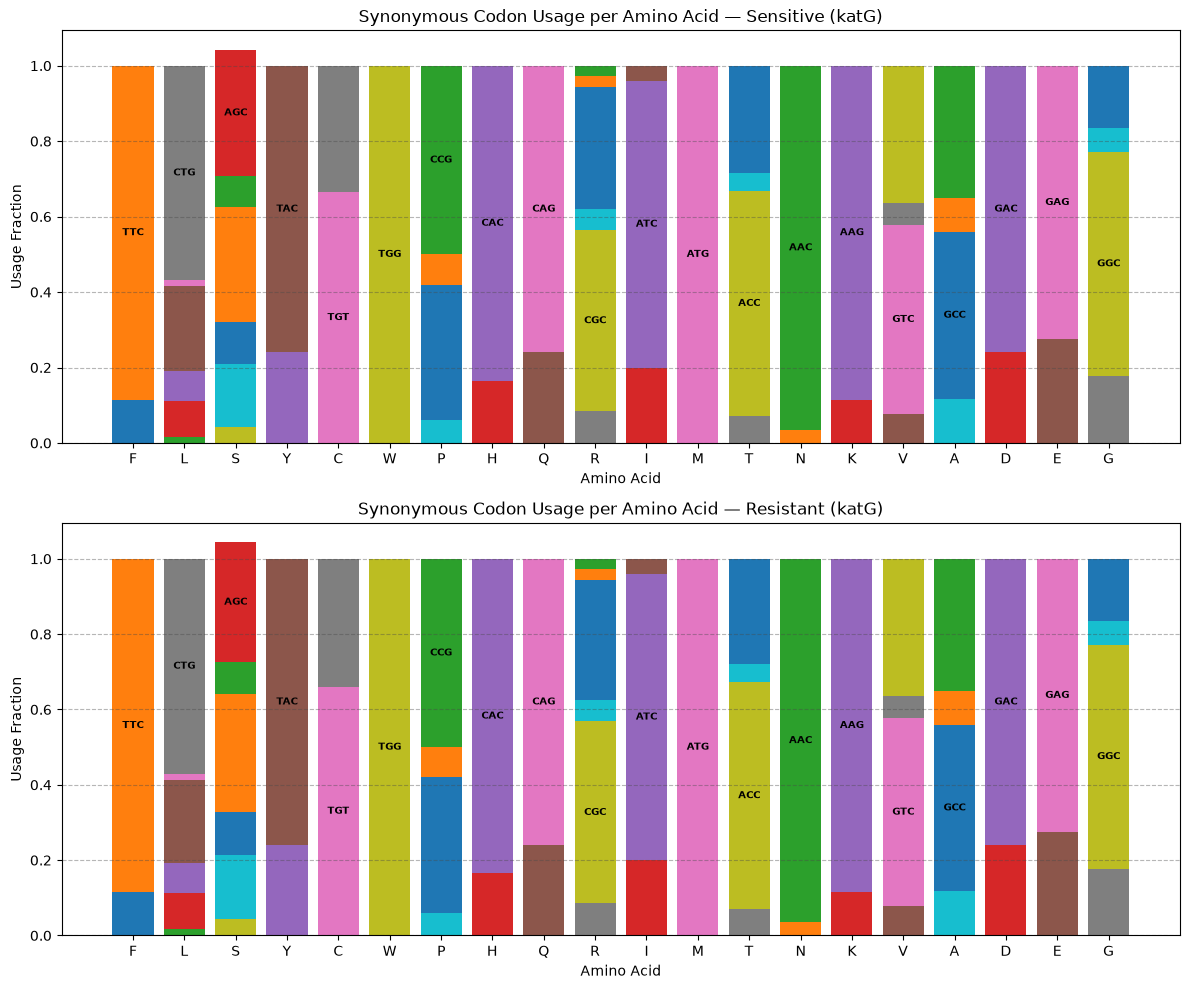

In [99]:
col = ["sensitive_frac","resistant_frac"]
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for i, grp in enumerate(col):
    ax = axes[i]
    label = grp.replace("_frac","").capitalize()
    for x in aa_to_codons_std:
        bottom = 0
        all_heights = []
        for codon in aa_to_codons_std[x]:
            match = rscu_avg_katG.loc[rscu_avg_katG["Codon"] == codon, grp]
            height = match.values[0] if not match.empty else 0
            all_heights.append(height)

        max_height = max(all_heights)

        for ht,codon in zip(all_heights,aa_to_codons_std[x]):
            ax.bar(x,height=ht,bottom=bottom)
            if ht == max_height:
                ax.text(x, bottom + ht/2, codon, ha="center", va="center", fontsize=7,fontweight="bold")
            bottom += ht
    ax.set_title(f"Synonymous Codon Usage per Amino Acid — {label} (katG)")
    ax.set_xlabel("Amino Acid")
    ax.set_ylabel("Usage Fraction")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4,color="#494a4a")
plt.tight_layout()
plt.savefig(os.path.join("..", "results", "plots", "codon_usage_stacked_katG.png"), dpi=300, bbox_inches="tight")
plt.show()


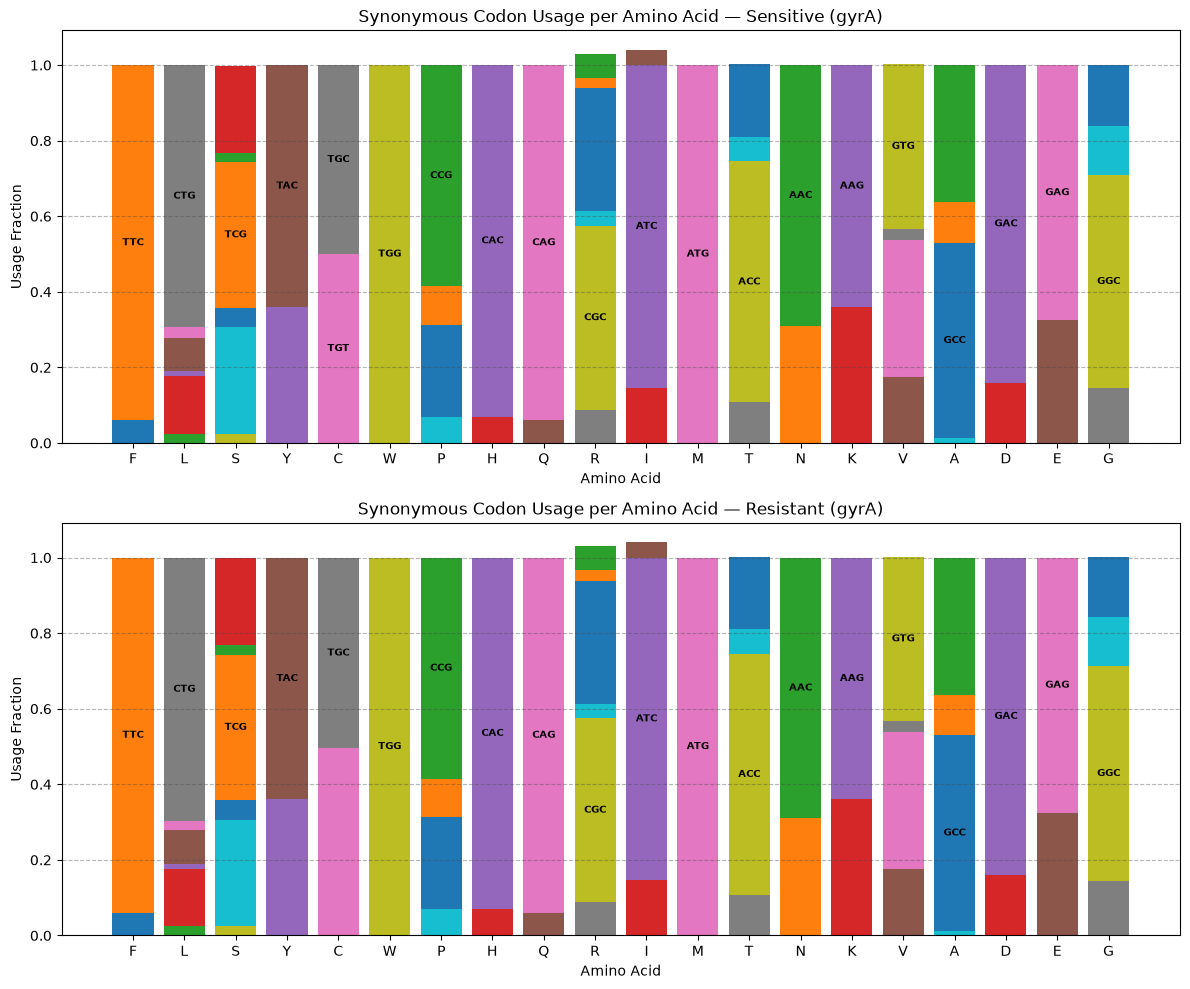

In [100]:
col = ["sensitive_frac","resistant_frac"]
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for i, grp in enumerate(col):
    ax = axes[i]
    label = grp.replace("_frac","").capitalize()
    for x in aa_to_codons_std:
        bottom = 0
        all_heights = []
        for codon in aa_to_codons_std[x]:
            match = rscu_avg_gyrA.loc[rscu_avg_gyrA["Codon"] == codon, grp]
            height = match.values[0] if not match.empty else 0
            all_heights.append(height)

        max_height = max(all_heights)

        for ht,codon in zip(all_heights,aa_to_codons_std[x]):
            ax.bar(x,height=ht,bottom=bottom)
            if ht == max_height:
                ax.text(x, bottom + ht/2, codon, ha="center", va="center", fontsize=7,fontweight="bold")
            bottom += ht
    ax.set_title(f"Synonymous Codon Usage per Amino Acid — {label} (gyrA)")
    ax.set_xlabel("Amino Acid")
    ax.set_ylabel("Usage Fraction")
    ax.grid(True, axis="y", linestyle="--", alpha=0.4,color="#494a4a")
plt.tight_layout()
plt.savefig(os.path.join("..", "results", "plots", "codon_usage_stacked_gyrA.png"), dpi=300, bbox_inches="tight")
plt.show()


# ***4. RSCU EVALUATIONS***

In [101]:
rscu_avg_rpoB.columns

Index(['Codon', 'Sensitive', 'Resistant', 'Difference', 'Absolute_Difference',
       'Percent_Change', 'third_base', 'base_category', 'Amino_acid',
       'n_codons', 'sensitive_frac', 'resistant_frac'],
      dtype='str')

In [102]:
rscu_avg_rpoB[["Codon","Sensitive","Resistant","Absolute_Difference","third_base","base_category"]].sort_values("Absolute_Difference",ascending=False).head(15)

,Codon,Sensitive,Resistant,Absolute_Difference,third_base,base_category
15,TCG,2.45,2.42,0.03,G,CG-ending
0,TTG,0.80,0.83,0.03,G,CG-ending
27,CTG,4.14,4.11,0.03,G,CG-ending
10,GCT,0.26,0.24,0.02,T,AT-ending
9,GCC,2.20,2.22,0.02,C,CG-ending
6,AGC,1.01,1.02,0.01,C,CG-ending
11,AGT,0.59,0.60,0.01,T,AT-ending
41,TCT,0.25,0.26,0.01,T,AT-ending
29,CTT,0.25,0.24,0.01,T,AT-ending
3,TCC,1.52,1.53,0.01,C,CG-ending


In [103]:
rscu_avg_gyrA[["Codon","Sensitive","Resistant","Absolute_Difference","third_base","base_category"]].sort_values("Absolute_Difference",ascending=False).head(15)

,Codon,Sensitive,Resistant,Absolute_Difference,third_base,base_category
57,CTA,0.17,0.15,0.02,A,AT-ending
27,CTG,4.16,4.18,0.02,G,CG-ending
39,GGC,2.26,2.27,0.01,C,CG-ending
55,TGT,1.00,0.99,0.01,T,AT-ending
45,TGC,1.00,1.01,0.01,C,CG-ending
5,CAG,1.88,1.88,0.00,G,CG-ending
6,AGC,1.38,1.38,0.00,C,CG-ending
7,AAA,0.72,0.72,0.00,A,AT-ending
8,ACA,0.26,0.26,0.00,A,AT-ending
1,GCA,0.43,0.43,0.00,A,AT-ending


In [104]:
rscu_avg_katG[["Codon","Sensitive","Resistant","Absolute_Difference","third_base","base_category"]].sort_values("Absolute_Difference",ascending=False).head(20)

,Codon,Sensitive,Resistant,Absolute_Difference,third_base,base_category
6,AGC,2.00,1.90,0.10,C,CG-ending
15,TCG,1.83,1.88,0.05,G,CG-ending
34,ACC,2.38,2.41,0.03,C,CG-ending
23,CGG,1.94,1.91,0.03,G,CG-ending
4,CGC,2.87,2.90,0.03,C,CG-ending
3,TCC,1.00,1.02,0.02,C,CG-ending
51,TCA,0.67,0.69,0.02,A,AT-ending
46,ACG,1.14,1.12,0.02,G,CG-ending
11,AGT,0.50,0.51,0.01,T,AT-ending
32,CTC,1.34,1.33,0.01,C,CG-ending


In [105]:
rscu_avg_rpoB[
    rscu_avg_rpoB["Absolute_Difference"] >= 0.01
]["base_category"].value_counts()

base_category
CG-ending    6
AT-ending    4
Name: count, dtype: int64

In [106]:
rscu_avg_gyrA[
    rscu_avg_gyrA["Absolute_Difference"] >= 0.01
]["base_category"].value_counts()

base_category
CG-ending    3
AT-ending    2
Name: count, dtype: int64

In [107]:
rscu_avg_katG[
    rscu_avg_katG["Absolute_Difference"] >= 0.01
]["base_category"].value_counts()

base_category
CG-ending    9
AT-ending    4
Name: count, dtype: int64

In [108]:
enc_gc3_all_samples[enc_gc3_all_samples["Group"]=="resistant"].head()

,Sample_ID,Group,enc_rpoB,gc3_rpoB,enc_katG,gc3_katG,enc_gyrA,gc3_gyrA
0,ERR4810461,resistant,34.23,0.8704,39.6,0.8286,38.82,0.8284
1,ERR4810467,resistant,34.23,0.8704,39.6,0.8286,38.82,0.8284
2,ERR4810478,resistant,34.23,0.8704,39.6,0.8286,38.82,0.8284
3,ERR4810485,resistant,34.23,0.8704,39.6,0.8286,38.82,0.8284
4,ERR4810486,resistant,34.23,0.8704,39.6,0.8286,38.82,0.8284


In [109]:
enc_gc3_all_samples[enc_gc3_all_samples["Group"]=="sensitive"].head()

,Sample_ID,Group,enc_rpoB,gc3_rpoB,enc_katG,gc3_katG,enc_gyrA,gc3_gyrA
5,ERR4810487,sensitive,34.49,0.8696,39.6,0.8286,38.82,0.8284
6,ERR4810488,sensitive,34.49,0.8696,39.6,0.8286,39.03,0.8272
7,ERR4810489,sensitive,34.49,0.8696,39.6,0.8286,38.82,0.8284
8,ERR4810491,sensitive,34.46,0.8696,39.6,0.8286,39.03,0.8272
9,ERR4810492,sensitive,34.49,0.8696,39.6,0.8286,39.03,0.8272


In [110]:
enc_gc3_all_samples.groupby("Group")[
    ["enc_rpoB","enc_katG","enc_gyrA"]
].describe()



enc_rpoB                                                       \
             count    mean       std    min    25%    50%    75%    max   
Group                                                                     
resistant     50.0  34.244  0.083324  34.08  34.23  34.23  34.23  34.49   
sensitive     50.0  34.353  0.129508  34.23  34.23  34.23  34.49  34.49   

          enc_katG           ...              enc_gyrA                     \
             count     mean  ...   75%    max    count     mean       std   
Group                        ...                                            
resistant     48.0  39.6075  ...  39.6  39.93     50.0  38.8060  0.132665   
sensitive     50.0  39.6000  ...  39.6  39.60     50.0  38.8872  0.098955   

                                              
             min    25%    50%    75%    max  
Group                                         
resistant  37.91  38.82  38.82  38.82  39.03  
sensitive  38.82  38.82  38.82  39.03  39.03  

[2 rows x 24 columns]

In [111]:
enc_gc3_all_samples.groupby("Group")["enc_katG"].describe()

,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
resistant,48.0,39.6075,4.773598e-02,39.6,39.6,39.6,39.6,39.93
sensitive,50.0,39.6000,7.177566e-15,39.6,39.6,39.6,39.6,39.60


In [112]:
enc_gc3_all_samples.groupby("Group")[
    ["gc3_rpoB","gc3_katG","gc3_gyrA"]
].describe()

gc3_rpoB                                                       \
             count      mean       std     min     25%      50%     75%   
Group                                                                     
resistant     50.0  0.870292  0.000263  0.8696  0.8704  0.87040  0.8704   
sensitive     50.0  0.869944  0.000502  0.8687  0.8696  0.86995  0.8704   

                  gc3_katG            ...                 gc3_gyrA            \
              max    count      mean  ...     75%     max    count      mean   
Group                                 ...                                      
resistant  0.8705     48.0  0.828573  ...  0.8286  0.8286     50.0  0.828384   
sensitive  0.8704     50.0  0.828596  ...  0.8286  0.8286     50.0  0.828028   

                                                            
                std    min     25%     50%     75%     max  
Group                                                       
resistant  0.000068  0.828  0.8284  0.8284  0.8284  0.8284  
sensitive  0.000602  0.826  0.8272  0.8284  0.8284  0.8284  

[2 rows x 24 columns]

In [113]:
enc_gc3_all_samples.groupby("Group")["gc3_katG"].describe()

,count,mean,std,min,25%,50%,75%,max
Group,,,,,,,,
resistant,48.0,0.828573,0.000188,0.8273,0.8286,0.8286,0.8286,0.8286
sensitive,50.0,0.828596,0.000028,0.8284,0.8286,0.8286,0.8286,0.8286


# ***5. Distribution Tests***

In [114]:
resitant_enc_rpoB = enc_gc3_all_samples[enc_gc3_all_samples["Group"]=="resistant"]["enc_rpoB"]
stats, p = shapiro(resitant_enc_rpoB)
print(p)

1.6913707847176192e-11


In [115]:
grp = ["resistant","sensitive"]
genes_data = ["enc_rpoB","enc_gyrA","enc_katG"]

for grp in grp:
    for col in genes_data:
        test = enc_gc3_all_samples[enc_gc3_all_samples["Group"] == grp][col]
        statt,p_value = shapiro(test)
        print(f"P-value: {grp.capitalize()} -> {col.replace("enc_","")} ---> {p_value}")


P-value: Resistant -> rpoB ---> 1.6913707847176192e-11
P-value: Resistant -> gyrA ---> 3.292810164770017e-15
P-value: Resistant -> katG ---> nan
P-value: Sensitive -> rpoB ---> 1.1734531779077823e-09
P-value: Sensitive -> gyrA ---> 1.295382092323551e-10
P-value: Sensitive -> katG ---> nan


In [116]:
grp = ["resistant","sensitive"]
genes_data = ["gc3_rpoB","gc3_gyrA","gc3_katG"]

for grp in grp:
    for col in genes_data:
        test = enc_gc3_all_samples[enc_gc3_all_samples["Group"] == grp][col]
        statt,p_value = shapiro(test)
        print(f"P-value: {grp.capitalize()} -> {col.replace("gc3_","")} ---> {p_value}")


P-value: Resistant -> rpoB ---> 4.0393814916108576e-12
P-value: Resistant -> gyrA ---> 1.5884072027083466e-14
P-value: Resistant -> katG ---> nan
P-value: Sensitive -> rpoB ---> 4.165567448955583e-08
P-value: Sensitive -> gyrA ---> 4.1547101186957415e-10
P-value: Sensitive -> katG ---> 1.127410019987875e-15


In [117]:
rscu_all_samples.head()

,Sample_Id,Group,Gene,Codon,RSCU,third_base,base_category
0,ERR4810461,resistant,rpoB,TTG,0.86,G,CG-ending
1,ERR4810461,resistant,rpoB,GCA,0.24,A,AT-ending
2,ERR4810461,resistant,rpoB,GAT,0.21,T,AT-ending
3,ERR4810461,resistant,rpoB,TCC,1.54,C,CG-ending
4,ERR4810461,resistant,rpoB,CGC,3.18,C,CG-ending


In [118]:
len(codon_to_aa)

61

In [119]:
group = ["resistant","sensitive"]
gene_list = ["rpoB","gyrA","katG"]

p_value_all_rscu = defaultdict(lambda:defaultdict(lambda:defaultdict(float)))
for grp in group:
    for gene in gene_list:
        for codon in codon_to_aa:
            test = rscu_all_samples[(rscu_all_samples["Group"] == grp) & 
                                (rscu_all_samples["Gene"] == gene) &
                                (rscu_all_samples["Codon"] == codon)]["RSCU"]
            if len(test) < 3:
                p = None
            else:
                stat, p = shapiro(test)
            p_value_all_rscu[grp][gene][codon] = p
p_value_all_rscu
        

defaultdict(<function __main__.<lambda>()>,
            {'resistant': defaultdict(<function __main__.<lambda>.<locals>.<lambda>()>,
                         {'rpoB': defaultdict(float,
                                      {'TTT': np.float64(1.127410019987875e-15),
                                       'TTC': np.float64(1.127410019987875e-15),
                                       'TTA': None,
                                       'TTG': np.float64(2.355729072459132e-09),
                                       'TCT': np.float64(4.209901313215688e-10),
                                       'TCC': np.float64(1.5224159512182383e-10),
                                       'TCA': np.float64(nan),
                                       'TCG': np.float64(9.190843886667494e-09),
                                       'TAT': np.float64(1.659964227818171e-14),
                                       'TAC': np.float64(1.659964227818171e-14),
                                       'TGT': np.fl

In [120]:
rows = []
for grp, info in p_value_all_rscu.items():
    for gene, cod_info in info.items():
        for codon, p in cod_info.items():
            rows.append({"Group":grp,
                         "Gene":gene,
                         "Codon":codon,
                         "P_value":p})

p_value_df = pd.DataFrame(rows)


In [121]:
p_value_df.head()

,Group,Gene,Codon,P_value
0,resistant,rpoB,TTT,1.127410e-15
1,resistant,rpoB,TTC,1.127410e-15
2,resistant,rpoB,TTA,NaN
3,resistant,rpoB,TTG,2.355729e-09
4,resistant,rpoB,TCT,4.209901e-10


In [122]:
p_value_df["P_value"].isna().sum()

np.int64(230)

In [123]:
p_value_df.shape

(366, 4)

In [124]:
p_value_df[p_value_df["P_value"].isna()].groupby(["Group","Gene"]).size()

Group      Gene
resistant  gyrA    38
           katG    36
           rpoB    18
sensitive  gyrA    36
           katG    54
           rpoB    48
dtype: int64

In [125]:
p_value_df[p_value_df["P_value"].isna()].groupby(["Group","Gene","Codon"]).size()

Group      Gene  Codon
resistant  gyrA  ACA      1
                 ACC      1
                 ACG      1
                 ACT      1
                 AGA      1
                         ..
sensitive  rpoB  TGT      1
                 TTA      1
                 TTC      1
                 TTG      1
                 TTT      1
Length: 230, dtype: int64

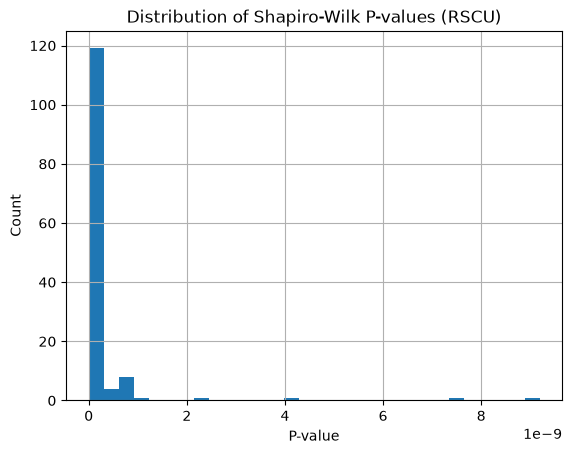

In [126]:
p_value_df["P_value"].dropna().hist(bins=30)
plt.xlabel("P-value")
plt.ylabel("Count")
plt.title("Distribution of Shapiro-Wilk P-values (RSCU)")
plt.show()

In [127]:
(p_value_df["P_value"] < 0.05).sum()

np.int64(136)

In [128]:
p_value_df.shape

(366, 4)

In [129]:
(p_value_df["P_value"] < 0.05).sum() / p_value_df["P_value"].notna().sum() *100

np.float64(100.0)

# ***6. MANN-WHITNEY TEST***

In [130]:
result = []
gene_list = ["rpoB","gyrA","katG"]

for gene in gene_list:
    for codon in codon_to_aa:
        sensitive_val = rscu_all_samples[
            (rscu_all_samples["Group"] == "sensitive") &
            (rscu_all_samples["Gene"] == gene) &
            (rscu_all_samples["Codon"] == codon)
        ]["RSCU"]
        resistant_val = rscu_all_samples[
            (rscu_all_samples["Group"] == "resistant") &
            (rscu_all_samples["Gene"] == gene) &
            (rscu_all_samples["Codon"] == codon)
        ]["RSCU"]
        if len(resistant_val) < 3 or len(sensitive_val) < 3:
            continue
        stat,p = mannwhitneyu(sensitive_val,resistant_val)
        result.append({"Gene":gene,"Codon":codon,"P_value":p})
mann_whitney_df = pd.DataFrame(result)



In [131]:
mann_whitney_df.head()

,Gene,Codon,P_value
0,rpoB,TTT,3.270861e-01
1,rpoB,TTC,3.270861e-01
2,rpoB,TTG,5.355494e-12
3,rpoB,TCT,7.546196e-11
4,rpoB,TCC,1.926737e-08


In [132]:
mann_whitney_df.describe()

,P_value
count,1.010000e+02
mean,1.978912e-01
std,2.844425e-01
min,3.286902e-18
25%,2.289100e-04
50%,8.218431e-02
75%,3.270861e-01
max,1.000000e+00


In [133]:
mann_whitney_df.shape

(177, 3)

In [134]:
mann_whitney_df["P_value"].isna().sum()

np.int64(76)

In [135]:
(mann_whitney_df["P_value"] < 0.05).sum()

np.int64(46)

In [136]:
(mann_whitney_df["P_value"] == 1.0).sum()

np.int64(9)

In [137]:
((mann_whitney_df["P_value"] < 1.0) & (mann_whitney_df["P_value"] > 0.05)).sum()

np.int64(46)

In [138]:
import sys; print(sys.executable)

/home/lummi/yes/envs/ngs_env/bin/python
